Сравнение классификации и времени классификации трансформера и ResNet

In [2]:
import torch
from torchvision import models, transforms
from PIL import Image
import time

from ml_dl_experiments import settings

filepath = settings.SOURCE_PATH+"ml_dl/cv/sheep.jpg"
image = Image.open(filepath).convert("RGB")

# Предобработка изображения (размер входа моделей 224х224)
preprocess = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

input_tensor = preprocess(image).unsqueeze(0)  # батч из 1

# Загрузка предобученных моделей
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2) # CNN
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1) # ViT

resnet.eval()
vit.eval()

# Инференс
with torch.no_grad():
    # ViT
    vit_start = time.time()
    vit_out = vit(input_tensor)
    vit_time = time.time() - vit_start
    # ResNet
    resnet_start = time.time()
    resnet_out = resnet(input_tensor)
    resnet_time = time.time() - resnet_start
    
# К этому моменту должны быть определены значения переменных resnet_time и vit_time

# Маппинг классов к названиям
resnet_labels = models.ResNet50_Weights.IMAGENET1K_V2.meta["categories"]
vit_labels = models.ViT_B_16_Weights.IMAGENET1K_V1.meta["categories"]

# Расчёт результатов
resnet_pred = resnet_out.argmax(1).item()
vit_pred = vit_out.argmax(1)

# Расчёт числа параметров
params_vit = sum(p.numel() for p in vit.parameters() if p.requires_grad)
params_resnet = sum(p.numel() for p in resnet.parameters() if p.requires_grad)

print(f"ResNet50 time: {resnet_time*1000:.2f} ms | Params: {params_resnet/1e6:.2f}M")
print(f"ViT-B/16 time:  {vit_time*1000:.2f} ms | Params: {params_vit/1e6:.2f}M")
print(f"ResNet50 predicts: {resnet_labels[resnet_pred]}")
print(f"ViT-B/16 predicts: {vit_labels[vit_pred]}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /home/ollldman/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:43<00:00, 8.00MB/s] 


ResNet50 time: 59.25 ms | Params: 25.56M
ViT-B/16 time:  156.41 ms | Params: 86.57M
ResNet50 predicts: ram
ViT-B/16 predicts: ram


Попробуем другой ViT

In [11]:
import torch
from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification
from torchvision import models

from ml_dl_experiments import settings
# Загрузка изображения
image = Image.open(settings.SOURCE_PATH+"ml_dl/cv/sheep.jpg").convert('RGB')
# Загрузка модели и предобработчика
model_name = 'google/vit-large-patch32-384'
processor = ViTImageProcessor.from_pretrained(model_name) # загрузка предобработчика
model = ViTForImageClassification.from_pretrained(model_name) # загрузка модели 
# Предобработка изображения
inputs = processor(images=image, return_tensors="pt") # image - входное изображение 
# Предсказание
with torch.no_grad():
    outputs = model(**inputs) # распаковка
pred = outputs.logits.argmax(dim=1)

vit_labels = models.ViT_B_16_Weights.IMAGENET1K_V1.meta["categories"]
print(f"Class is: {vit_labels[pred.item()]}")

Class is: ram


Попробуем достать предсказание вместе с маской внимания:

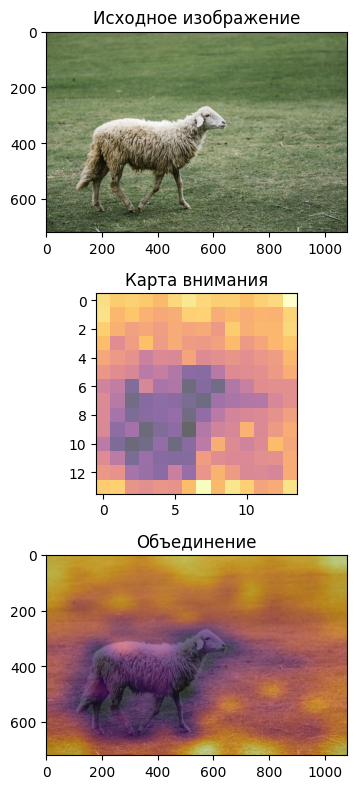

In [2]:
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image, ImageFilter
import numpy as np
import matplotlib.pyplot as plt

from ml_dl_experiments import settings


# Сумма внимания по всем головам multi-head attention
def attention_rollout(attentions):
    # Создание промежуточной матрицы - единичной, размером с количество токенов, 
    # на том же устройстве
    # Сначала матрица единичная, так как для каждого токена важен только он сам
    rollout = torch.eye(attentions[0].size(-1)).to(attentions[0].device)
    # Промежуточная матрица домножается на внимание, полученное для каждого токена
    # В каждой голове multi-head attention
    for attention in attentions:
        attention_heads_fused = attention.mean(dim=1)
        attention_heads_fused += torch.eye(attention_heads_fused.size(-1)).to(
            attention_heads_fused.device
        )
        attention_heads_fused /= attention_heads_fused.sum(dim=-1, keepdim=True)
        rollout = torch.matmul(rollout, attention_heads_fused)
    return rollout

# Загрузка изображения
image = Image.open(settings.SOURCE_PATH+"ml_dl/cv/sheep.jpg").convert('RGB')

# Загрузка модели и препроцессора
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name,attn_implementation="eager")  # Добавили eager

# Предобработка
inputs = processor(images=image, return_tensors="pt")

# Предсказание
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True) # Добавили output_attentions=True

attentions = outputs.attentions
rollout = attention_rollout(attentions)

# Извлечение обобщённого внимания из CLS-токена
cls_attention = rollout[0, 1:, 0] 

# преобразование маски внимания в изображение
# матрица внимания имеет размер NxN, где N - количество патчей, поэтому
# для получения их количества нужно взять квадратный корень от размера матрицы
num_patches = int(cls_attention.shape[0] ** 0.5)
# превращение вектора внимания в матрицу, чтобы наложить на изображение
cls_attention = cls_attention.reshape(num_patches, num_patches).cpu().numpy()

# перевод значений внимания в диапазон от 0 до 1
cls_attention_n = (cls_attention - cls_attention.min()) / (
    cls_attention.max() - cls_attention.min()
)
# преобразование маски внимания в изображение
cls_attention_resized = Image.fromarray((cls_attention_n * 255).astype(np.uint8)).resize(
    image.size, resample=Image.BICUBIC
)

# Визуализация изображения с наложенной на него тепловой картой внимания
fig, ax = plt.subplots(3, 1, figsize=(8, 8))
ax[0].imshow(image)
ax[1].imshow(cls_attention, cmap="inferno", alpha=0.6)
ax[1].set_title("Карта внимания")
ax[0].set_title("Исходное изображение")
ax[2].imshow(image)
ax[2].imshow(cls_attention_resized, cmap="inferno", alpha=0.6)
ax[2].set_title("Объединение")
fig.tight_layout()
plt.show()